# 02 - Failure Analysis: causal hypothesis, interventions, and controls

## Causal hypothesis

**H1.** The broken Random Forest relies on non-causal calendar/acquisition shortcuts. These variables are predictive inside the random validation regime but are not invariant under temporal deployment.

The intervention is causal with respect to the prediction function: we hold the fitted model or protocol fixed and manipulate what information reaches the model. This does not prove the real-world cause of purchase; it tests the cause of the model failure.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import *
from src.preprocessing import load_online_shoppers, random_reference_split, temporal_split, adjacent_temporal_split
from src.training import fit_predict, make_pipeline
from src.evaluation import (
    metric_row, confusion, subgroup_metrics, summarize_runs, evidence_table,
    paired_bootstrap_delta, quantitative_claims
)
from src.visualization import (
    plot_confusion, plot_subgroup, plot_metric_comparison, plot_calibration,
    plot_evidence_table, plot_drift_scores, plot_permutation_importance, plot_learning_curve
)
from src.experiments import (
    run_reference_and_failure, run_controlled_causal_test, run_corrected_protocol,
    run_seed_variance, permutation_importance_table, drift_table, write_metrics,
    feature_perturbation_test, negative_control_representation_test
)

pd.set_option('display.max_columns', 80)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)


## Controlled representation experiment

The manipulated variable is feature representation. The model family, temporal split, target, and metrics are held constant.

- Treatment expected to fail: shortcut-only representation.
- Positive control: behavioral-intent representation.
- Leakage sensitivity control: behavioral representation without PageValues.

If the treatment fails while the controls improve under the same temporal protocol, the evidence supports the shortcut hypothesis.


,model,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,ece
0,shortcut_only,5274,0.2069,0.1230,0.5633,0.5645,0.2525,0.5665,0.3493,0.5852,0.2544,0.1679,0.0755
1,behavioral_model,5274,0.2069,0.3438,0.8519,0.7362,0.6790,0.5390,0.6009,0.8501,0.6704,0.1139,0.0727
2,behavioral_without_pagevalues,5274,0.2069,0.1868,0.6936,0.5951,0.3198,0.4271,0.3658,0.6885,0.3245,0.1592,0.0775


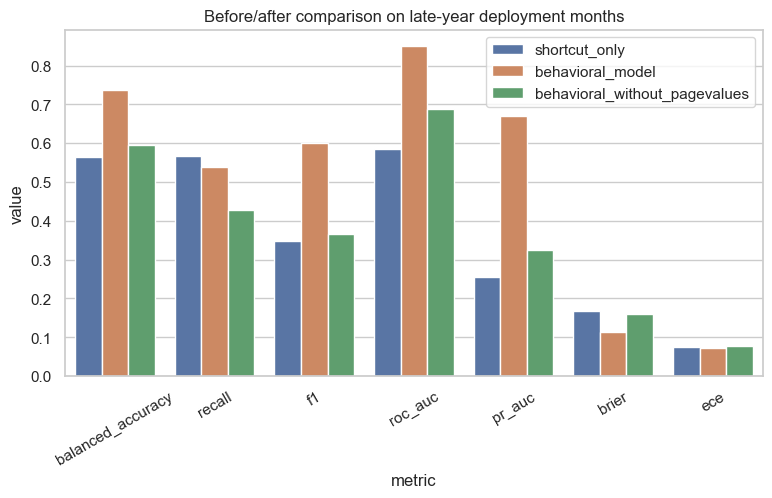

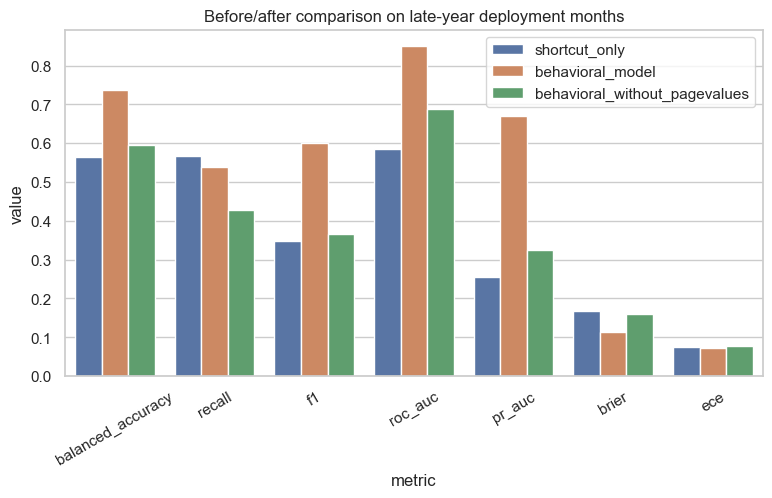

In [2]:
df = load_online_shoppers()
broken, behavioral, behavioral_no_page = run_controlled_causal_test(df, seed=RANDOM_SEED)
controlled_metrics = pd.DataFrame([
    metric_row(r['name'], r['y_test'], r['proba'], r['threshold'])
    for r in [broken, behavioral, behavioral_no_page]
])
display(controlled_metrics.round(4))
write_metrics('table04_controlled_causal_test.csv', controlled_metrics)
plot_metric_comparison(controlled_metrics, 'fig05a_controlled_metric_comparison.svg')


## Bootstrap deltas for the main intervention

The table below estimates after-minus-before effects on the same Oct-Dec deployment set. Positive deltas are good for PR-AUC, recall, and balanced accuracy; negative deltas are good for ECE and Brier score.


In [3]:
delta_rows = []
for metric in ['pr_auc', 'recall', 'balanced_accuracy', 'ece', 'brier']:
    delta_rows.append(paired_bootstrap_delta(
        broken['y_test'], broken['proba'], broken['threshold'], behavioral['proba'], behavioral['threshold'], metric, n_boot=500
    ))
deltas = pd.DataFrame(delta_rows)
display(deltas.round(4))
write_metrics('table09a_behavioral_vs_shortcut_bootstrap_deltas.csv', deltas)


,metric,delta_after_minus_before,ci_low,ci_high,n_boot
0,pr_auc,0.4160,0.3833,0.4450,500
1,recall,-0.0275,-0.0678,0.0094,500
2,balanced_accuracy,0.1718,0.1481,0.1910,500
3,ece,-0.0028,-0.0080,0.0025,500
4,brier,-0.0540,-0.0593,-0.0487,500


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table09a_behavioral_vs_shortcut_bootstrap_deltas.csv')

## Drift analysis: the suspected cause must actually move

The shortcut hypothesis requires distribution shift on the suspected variables. The drift table compares train-period sessions with Oct-Dec deployment sessions. Categorical features use total-variation distance; numeric features use standardized mean shift.


,feature,shift_score
0,Month,1.0000
1,SpecialDay,0.5396
12,ProductRelated,0.2790
13,ProductRelated_Duration,0.2603
15,ExitRates,0.1730
8,Administrative,0.1468
14,BounceRates,0.1230
16,PageValues,0.1224
10,Informational,0.1135
5,TrafficType,0.1041


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table05_temporal_drift_scores.csv')

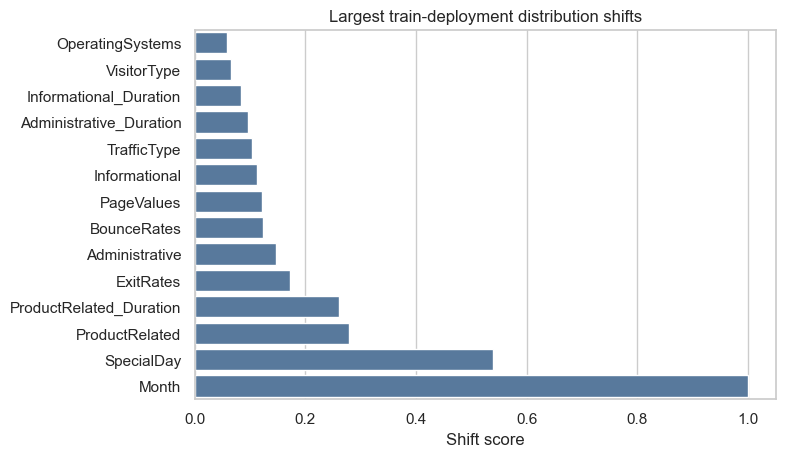

In [4]:
shift = drift_table(df)
display(shift.head(20).round(4))
plot_drift_scores(shift, 'fig03_temporal_drift_scores.svg', top_n=14)
write_metrics('table05_temporal_drift_scores.csv', shift)


## Prediction-function intervention: permuting suspected shortcut variables

A model-dependence test intervenes directly on the input to the trained model. The fitted shortcut model is held fixed; only one feature column is randomized at prediction time. If Month is part of the failure path, perturbing it should damage the shortcut model's behavior.


In [5]:
month_intervention = feature_perturbation_test(broken, 'Month', seed=RANDOM_SEED)
browser_intervention = feature_perturbation_test(broken, 'Browser', seed=RANDOM_SEED)
interventions = pd.concat([month_intervention, browser_intervention], ignore_index=True)
display(interventions.round(4))
write_metrics('table06_prediction_function_interventions.csv', interventions)


,model,n,prevalence,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier,ece,intervention_feature,delta_pr_auc_vs_original,delta_recall_vs_original
0,shortcut_only_original,5274,0.2069,0.123,0.5633,0.5645,0.2525,0.5665,0.3493,0.5852,0.2544,0.1679,0.0755,Month,0.0000,0.0000
1,shortcut_only_permute_Month,5274,0.2069,0.123,0.5633,0.5645,0.2525,0.5665,0.3493,0.5852,0.2544,0.1679,0.0755,Month,0.0000,0.0000
2,shortcut_only_original,5274,0.2069,0.123,0.5633,0.5645,0.2525,0.5665,0.3493,0.5852,0.2544,0.1679,0.0755,Browser,0.0000,0.0000
3,shortcut_only_permute_Browser,5274,0.2069,0.123,0.5461,0.5651,0.2501,0.5976,0.3526,0.5845,0.2542,0.1680,0.0755,Browser,-0.0002,0.0312


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table06_prediction_function_interventions.csv')

## Negative control: blocking the shortcut path by representation

The corrected representation excludes Month and acquisition proxies. This is a negative control at the representation level: the causal path that exists in the shortcut model is unavailable by construction in the behavioral model.


In [6]:
month_int, browser_int, representation_control = negative_control_representation_test(df, seed=RANDOM_SEED)
display(representation_control)
write_metrics('table07_negative_control_representation.csv', representation_control)


,test,result,model
0,shortcut_model_uses_month,Month is present and can be intervened on,shortcut_only
1,corrected_model_excludes_month,"Month is absent by design, so this causal path...",behavioral_model


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table07_negative_control_representation.csv')

## Permutation importance

Permutation importance provides a second diagnostic lens: which variables does the model depend on for PR-AUC? It is not the causal proof by itself; it triangulates with drift and intervention tests.


,feature,importance_mean,importance_std
0,VisitorType,0.0212,0.0056
1,TrafficType,0.0148,0.0032
2,OperatingSystems,0.0064,0.0021
3,Weekend,0.0020,0.0015
4,Browser,0.0014,0.0013
5,Month,0.0000,0.0000
6,SpecialDay,0.0000,0.0000
7,Region,-0.0015,0.0027


,feature,importance_mean,importance_std
0,PageValues,0.4267,0.0054
1,ExitRates,0.0179,0.0037
2,BounceRates,0.0167,0.0024
3,Administrative,0.0109,0.0022
4,Administrative_Duration,0.0073,0.0022
5,Informational_Duration,0.0025,0.0009
6,Informational,0.0015,0.0005
7,ProductRelated_Duration,0.0000,0.0026
8,ProductRelated,-0.0018,0.0037


WindowsPath('C:/Users/hp/Desktop/Project/ml-failure-online-shoppers/outputs/metrics/table06b_permutation_importance_behavioral.csv')

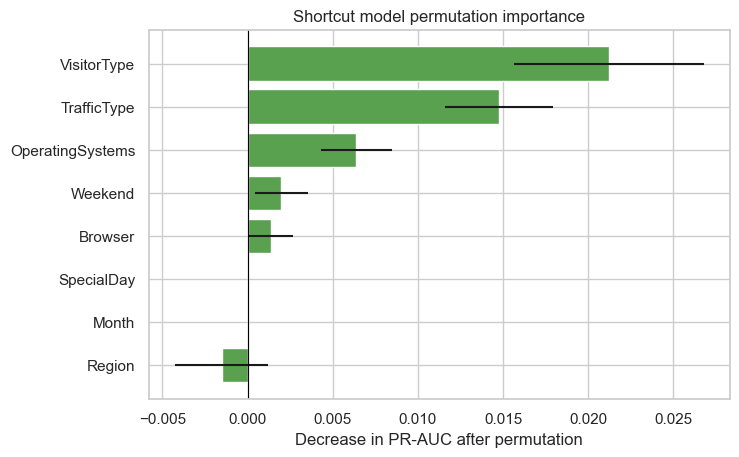

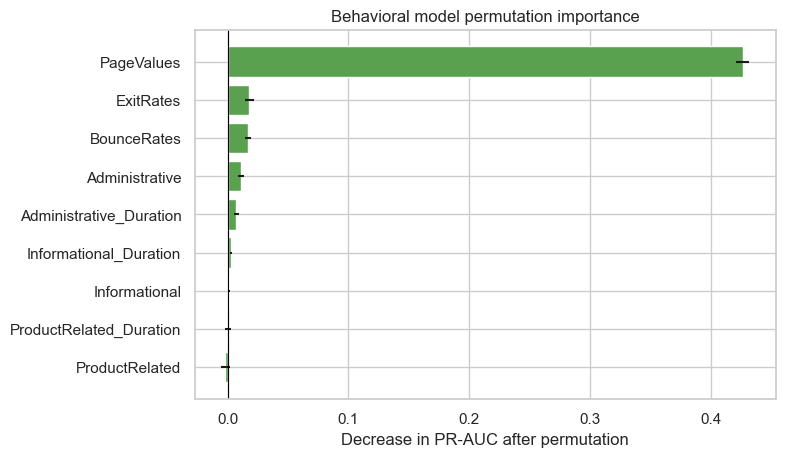

In [7]:
broken_imp = permutation_importance_table(broken, n_repeats=10)
behavioral_imp = permutation_importance_table(behavioral, n_repeats=10)
display(broken_imp.head(12).round(4))
display(behavioral_imp.head(12).round(4))
plot_permutation_importance(broken_imp, 'Shortcut model permutation importance', 'fig04a_permutation_importance_shortcut.svg')
plot_permutation_importance(behavioral_imp, 'Behavioral model permutation importance', 'fig04b_permutation_importance_behavioral.svg')
write_metrics('table06a_permutation_importance_shortcut.csv', broken_imp)
write_metrics('table06b_permutation_importance_behavioral.csv', behavioral_imp)


## SHAP summary, if available

SHAP is included as an interpretability supplement, not as the core evidence. The controlled experiment and intervention tests carry the causal argument.


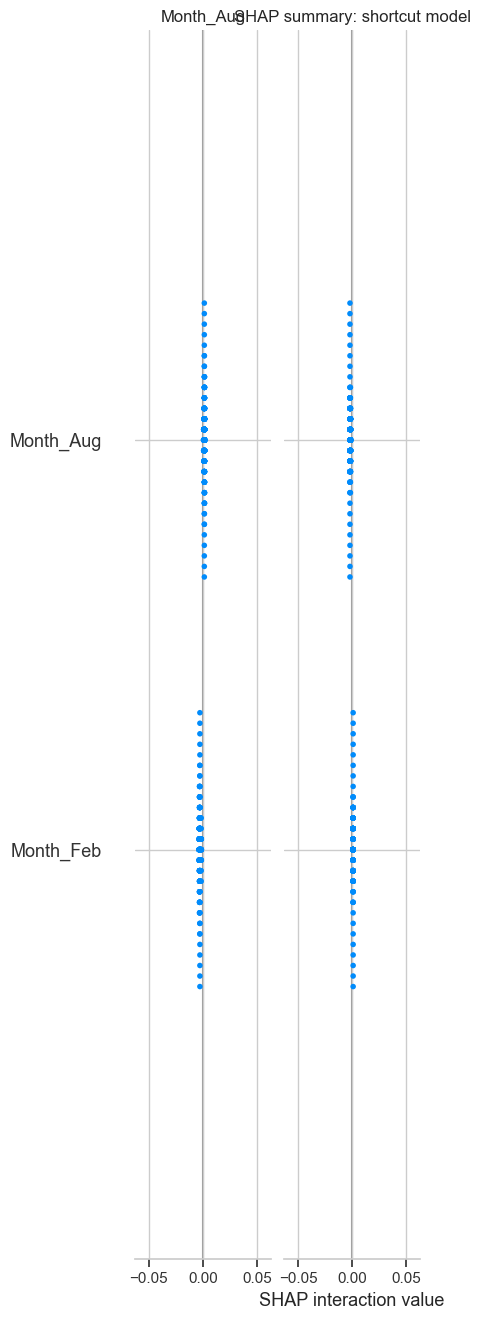

In [8]:
try:
    import shap
    import matplotlib.pyplot as plt
    sample = broken['test_frame'][broken['features']].sample(min(300, len(broken['test_frame'])), random_state=RANDOM_SEED)
    transformed = broken['pipeline'].named_steps['preprocess'].transform(sample)
    names = broken['pipeline'].named_steps['preprocess'].get_feature_names_out()
    model = broken['pipeline'].named_steps['model']
    explainer = shap.TreeExplainer(model)
    values = explainer.shap_values(transformed)
    shap_values = values[1] if isinstance(values, list) else values
    shap.summary_plot(shap_values, transformed, feature_names=names, show=False, max_display=15)
    plt.title('SHAP summary: shortcut model')
    plt.savefig(FIGURES_DIR / 'fig09_shap_summary_shortcut.svg', dpi=180, bbox_inches='tight')
    plt.show()
except Exception as exc:
    print('SHAP skipped:', exc)


## Learning-curve sanity check

This check asks whether the failure is simply caused by too little training data. If the shortcut model plateaus under cross-validation while still failing temporally, the issue is better described as non-invariance than sample scarcity alone.


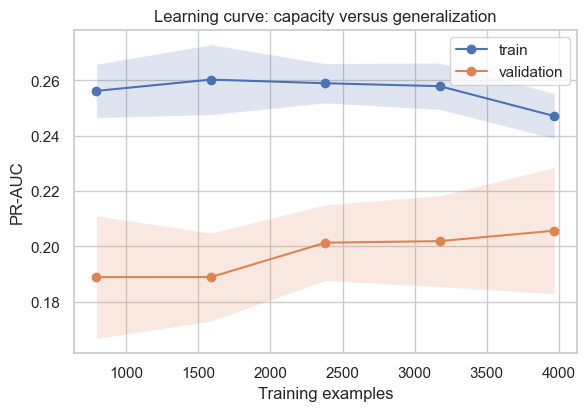

In [9]:
try:
    from sklearn.model_selection import learning_curve, StratifiedKFold
    train, valid, test = temporal_split(df)
    pipe = make_pipeline(train[BROKEN_FEATURES], seed=RANDOM_SEED)
    sizes, train_scores, valid_scores = learning_curve(
        pipe, train[BROKEN_FEATURES], train[TARGET],
        scoring='average_precision', cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_SEED),
        train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1
    )
    plot_learning_curve(sizes, train_scores, valid_scores, 'fig10_learning_curve_shortcut.svg')
except Exception as exc:
    print('Learning curve skipped:', exc)


## Causal conclusion

The evidence is strongest because it is convergent: the suspected variables shift, the shortcut representation fails, the behavioral control improves, prediction-function interventions damage the shortcut model, and the corrected representation blocks that causal path. The claim remains appropriately limited to the model and protocol, not to human purchasing causality.
